In [1]:
import random
import pandas as pd
import numpy as np
import xgboost as xgb
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [2]:
random.seed(42)
np.random.seed(42)

# Load File

In [ ]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")
test = pd.read_csv("test.csv")


TARGET = "is_viral"

# Sentiment feature

In [4]:
BERT_SENTIMENT_COLS = [
    "bert_title_compound", "bert_title_extreme", "bert_title_is_pos", "bert_title_is_neg",
    "bert_ocr_compound",   "bert_ocr_extreme",   "bert_ocr_is_pos",   "bert_ocr_is_neg",
]

# Sanity check: confirm columns exist and have no nulls
for df, name in [(train, "train"), (val, "val"), (test, "test")]:
    missing = [c for c in BERT_SENTIMENT_COLS if c not in df.columns]
    if missing:
        print(f"[{name}] MISSING: {missing}")
    else:
        nulls = df[BERT_SENTIMENT_COLS].isnull().sum().sum()
        print(f"[{name}] All DistilBERT columns present. Null count: {nulls}")

print()
print("Sample DistilBERT scores (train):")
print(train[BERT_SENTIMENT_COLS].describe().round(4))

[train] All DistilBERT columns present. Null count: 0
[val] All DistilBERT columns present. Null count: 0
[test] All DistilBERT columns present. Null count: 0

Sample DistilBERT scores (train):
       bert_title_compound  bert_title_extreme  bert_title_is_pos  \
count            3374.0000           3374.0000          3374.0000   
mean               -0.2700              0.9564             0.3607   
std                 0.9221              0.0914             0.4803   
min                -0.9998              0.5003             0.0000   
25%                -0.9952              0.9681             0.0000   
50%                -0.9624              0.9931             0.0000   
75%                 0.9805              0.9984             1.0000   
max                 0.9999              0.9999             1.0000   

       bert_title_is_neg  bert_ocr_compound  bert_ocr_extreme  \
count          3374.0000          3374.0000         3374.0000   
mean              0.6393            -0.6117           

# Features

In [5]:
CATEGORICAL_COLS = ["Category", "Time of Day", "post_day"]
NUMERIC_COLS     = ["title_len", "ocr_len", "post_hour", "account_age_days"]
SENTIMENT_COLS = BERT_SENTIMENT_COLS

# Encoder

In [6]:
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    val[col]   = le.transform(val[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    encoders[col] = le

# Construct other features

In [7]:
for df in [train, val, test]:
    df["log_total_karma"]   = np.log1p(df["Total Karma"].clip(lower=0))
    df["log_comment_karma"] = np.log1p(df["Comment Karma"].clip(lower=0))

META_COLS    = CATEGORICAL_COLS + NUMERIC_COLS + ["log_total_karma", "log_comment_karma"]
FEATURE_COLS = META_COLS + SENTIMENT_COLS

In [8]:
print(f"Total features: {len(FEATURE_COLS)}")
print("Features:", FEATURE_COLS)

Total features: 17
Features: ['Category', 'Time of Day', 'post_day', 'title_len', 'ocr_len', 'post_hour', 'account_age_days', 'log_total_karma', 'log_comment_karma', 'bert_title_compound', 'bert_title_extreme', 'bert_title_is_pos', 'bert_title_is_neg', 'bert_ocr_compound', 'bert_ocr_extreme', 'bert_ocr_is_pos', 'bert_ocr_is_neg']


#Set up dfs

In [9]:
X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val, y_val = val[FEATURE_COLS], val[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

# Evaluation helper

In [10]:
def evaluate(model, X, y, split_name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    print(f"\n{'='*55}")
    print(f" {split_name}")
    print(f"{'='*55}")
    print(f"Accuracy: {accuracy_score(y, preds):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y, probs):.4f}")
    print(f"F1 (macro): {f1_score(y, preds, average='macro'):.4f}")
    print(f"F1 (viral): {f1_score(y, preds, pos_label=1):.4f}")

# Baseline

In [11]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")


Class imbalance ratio (scale_pos_weight): 3.00


In [12]:
baseline = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)


baseline.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
evaluate(baseline, X_train, y_train, "Train")
evaluate(baseline, X_val,   y_val,   "Validation")
evaluate(baseline, X_test,  y_test,  "Test")


 Train
Accuracy: 0.9905
ROC-AUC: 0.9998
F1 (macro): 0.9875
F1 (viral): 0.9814

 Validation
Accuracy: 0.7040
ROC-AUC: 0.6642
F1 (macro): 0.6057
F1 (viral): 0.4088

 Test
Accuracy: 0.6920
ROC-AUC: 0.6403
F1 (macro): 0.5688
F1 (viral): 0.3383


# Hyperparameter Tuning

In [14]:
param_dist = {
    "n_estimators" : [200, 400, 600, 800],
    "max_depth" : [3, 4, 5, 6, 8],
    "learning_rate" : [0.01, 0.05, 0.1, 0.2],
    "subsample" : [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.5, 0.6, 0.7, 0.8, 1.0],
    "min_child_weight" : [1, 3, 5, 7],
    "gamma" : [0, 0.1, 0.3, 0.5, 1.0],
    "reg_alpha" : [0, 0.01, 0.1, 1.0],
    "reg_lambda" : [0.5, 1.0, 2.0, 5.0],
}

xgb_tuner = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    xgb_tuner,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

best_model = search.best_estimator_

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best CV ROC-AUC: 0.6583
Best params: {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}


# Tuned Result

In [15]:
evaluate(best_model, X_train, y_train, "Train")
evaluate(best_model, X_val, y_val, "Validation")
evaluate(best_model, X_test, y_test, "Test")


 Train
Accuracy: 0.6749
ROC-AUC: 0.7874
F1 (macro): 0.6460
F1 (viral): 0.5450

 Validation
Accuracy: 0.6072
ROC-AUC: 0.6959
F1 (macro): 0.5790
F1 (viral): 0.4701

 Test
Accuracy: 0.5912
ROC-AUC: 0.6573
F1 (macro): 0.5623
F1 (viral): 0.4498


# Plots

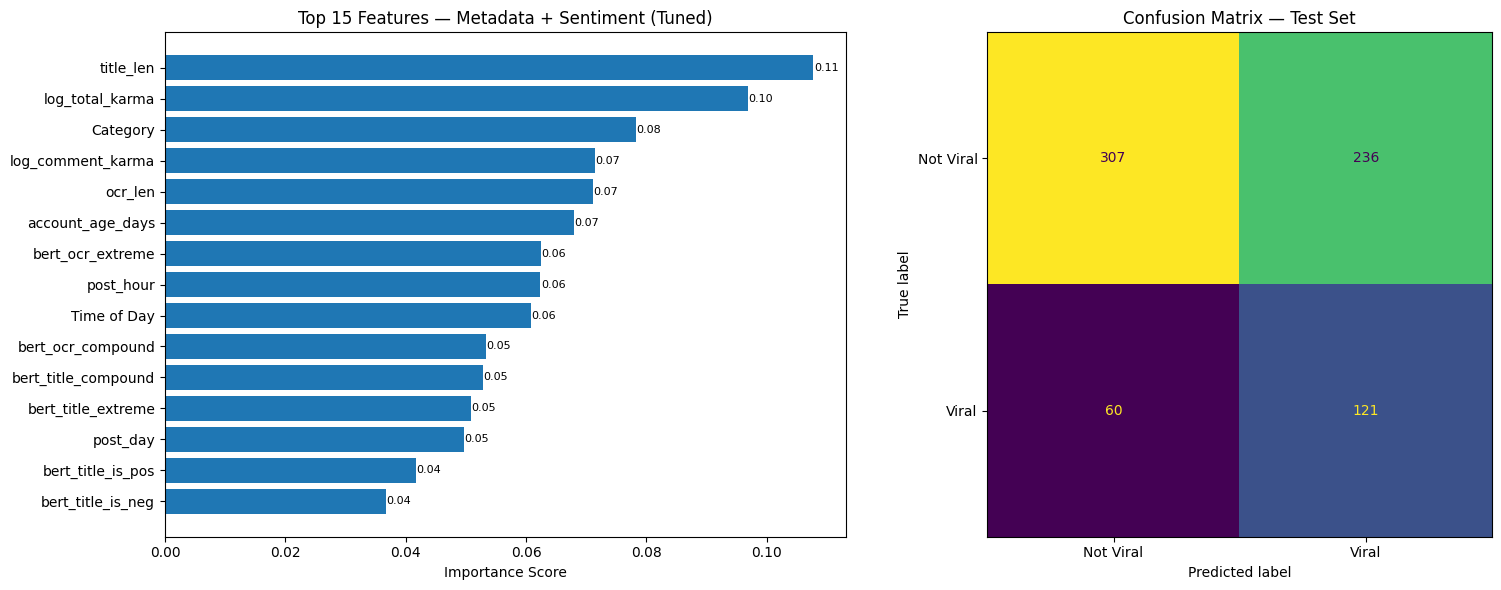

In [16]:
importance_df = pd.DataFrame({
    "feature"   : FEATURE_COLS,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
top15 = importance_df.head(15)
axes[0].barh(top15["feature"][::-1], top15["importance"][::-1])
axes[0].set_xlabel("Importance Score")
axes[0].set_title("Top 15 Features — Metadata + Sentiment (Tuned)")
for i, v in enumerate(top15["importance"][::-1]):
    axes[0].text(v + 0.0001, i, f"{v:.2f}", va="center", fontsize=8)

# Confusion matrix
test_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Viral", "Viral"])
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — Test Set")

plt.tight_layout()
plt.show()

# Summary

In [17]:
rows = []
for model_name, model in [("Baseline", baseline), ("Tuned", best_model)]:
    for split_name, X, y in [("Train", X_train, y_train),
                               ("Val", X_val, y_val),
                               ("Test", X_test, y_test)]:
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]
        rows.append({
            "Model" : model_name,
            "Split" : split_name,
            "Accuracy": round(accuracy_score(y, preds), 4),
            "ROC-AUC" : round(roc_auc_score(y, probs),  4),
            "F1-macro": round(f1_score(y, preds, average="macro"), 4),
            "F1-viral": round(f1_score(y, preds, pos_label=1), 4),
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

   Model Split  Accuracy  ROC-AUC  F1-macro  F1-viral
Baseline Train    0.9905   0.9998    0.9875    0.9814
Baseline   Val    0.7040   0.6642    0.6057    0.4088
Baseline  Test    0.6920   0.6403    0.5688    0.3383
   Tuned Train    0.6749   0.7874    0.6460    0.5450
   Tuned   Val    0.6072   0.6959    0.5790    0.4701
   Tuned  Test    0.5912   0.6573    0.5623    0.4498
